In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4

In [5]:
fpath = '/pl/active/kaygroup/CERES-EBAF/CERES_EBAF-TOA_Ed4.2.1_Subset_200003-202507.nc'
ds = xr.open_dataset(fpath)

# Quick Visualization

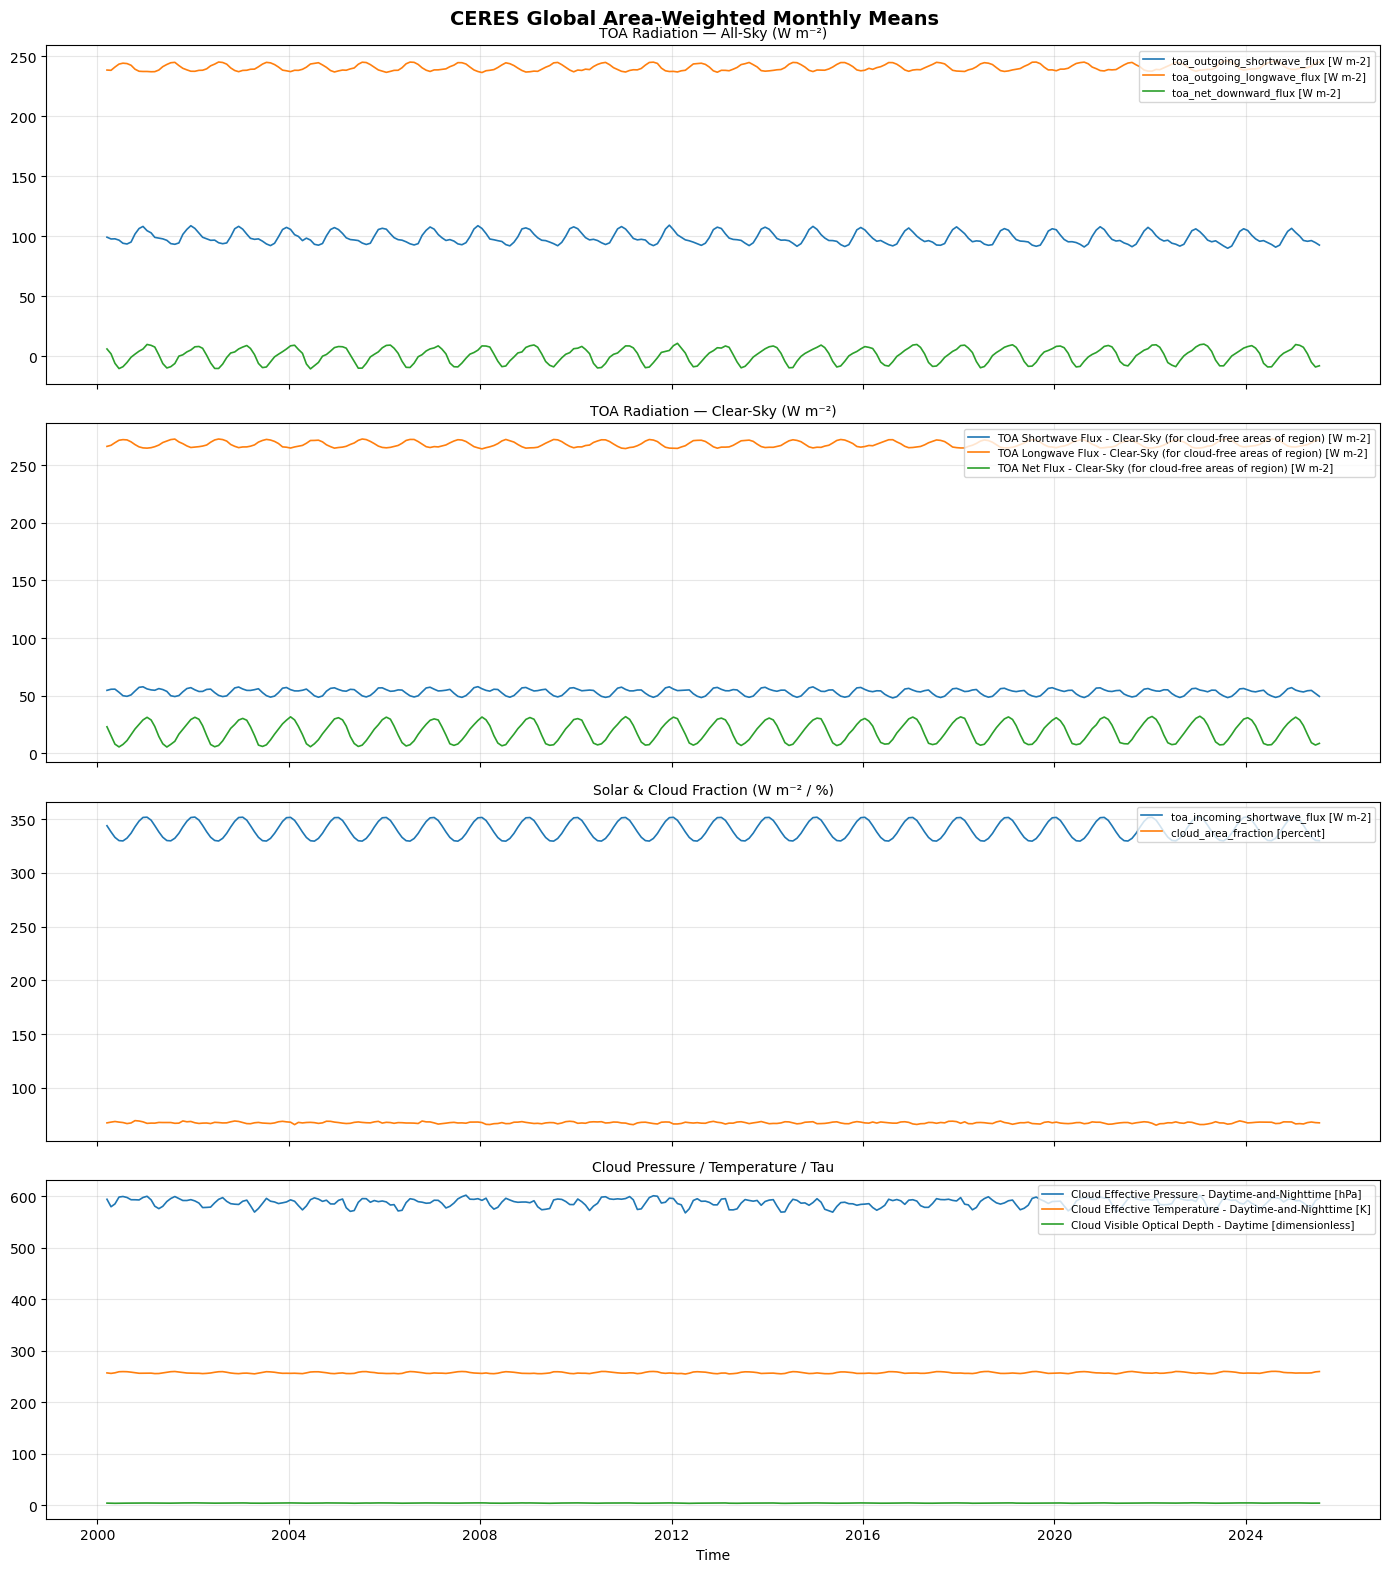

In [7]:
# --- Area-weighted global mean ---
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"
global_mean = ds.weighted(weights).mean(dim=["lat", "lon"])

# --- Helper: get best label (CF_name if available, else standard_name) ---
def get_label(ds, var):
    attrs = ds[var].attrs
    cf = attrs.get("CF_name", "none")
    return cf if cf != "none" else attrs.get("standard_name", var)

# --- Group variables by units for subplots ---
vars_to_plot = {
    "TOA Radiation — All-Sky (W m⁻²)":        ["toa_sw_all_mon", "toa_lw_all_mon", "toa_net_all_mon"],
    "TOA Radiation — Clear-Sky (W m⁻²)":       ["toa_sw_clr_c_mon", "toa_lw_clr_c_mon", "toa_net_clr_c_mon"],
    "Solar & Cloud Fraction (W m⁻² / %)":      ["solar_mon", "cldarea_total_daynight_mon"],
    "Cloud Pressure / Temperature / Tau":       ["cldpress_total_daynight_mon", "cldtemp_total_daynight_mon", "cldtau_total_day_mon"],
}

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(14, 16), sharex=True)
fig.suptitle("CERES Global Area-Weighted Monthly Means", fontsize=14, fontweight="bold")

colors = plt.cm.tab10.colors
time = global_mean.time.values

for ax, (title, variables) in zip(axes, vars_to_plot.items()):
    for i, var in enumerate(variables):
        label = get_label(ds, var)
        units = ds[var].attrs.get("units", "")
        ax.plot(time, global_mean[var].values, label=f"{label} [{units}]", color=colors[i], linewidth=1.2)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time")
plt.tight_layout()
# plt.savefig("ceres_global_means.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

## Visualize ASR and OLR by surface type

Use `regionmask` to stratify by surface, 

TODO: use IGBP classification map in the future.

In [ ]:
import regionmask

## But now with trend lines

In [20]:
from scipy import stats

def add_trend(ax, time, values, color):
    """Fit and plot a linear trend line, annotate with slope."""
    x = np.arange(len(time))
    slope, intercept, r, p, _ = stats.linregress(x, values)
    trend = slope * x + intercept
    # slope in units/month → convert to /decade
    slope_dec = slope * 120
    ax.plot(time, trend, color=color, linewidth=1.5, linestyle="--",
            alpha=0.85, label=f"trend: {slope_dec:+.3f} W m⁻² dec⁻¹")
    ax.legend(fontsize=7.5, loc="upper right")

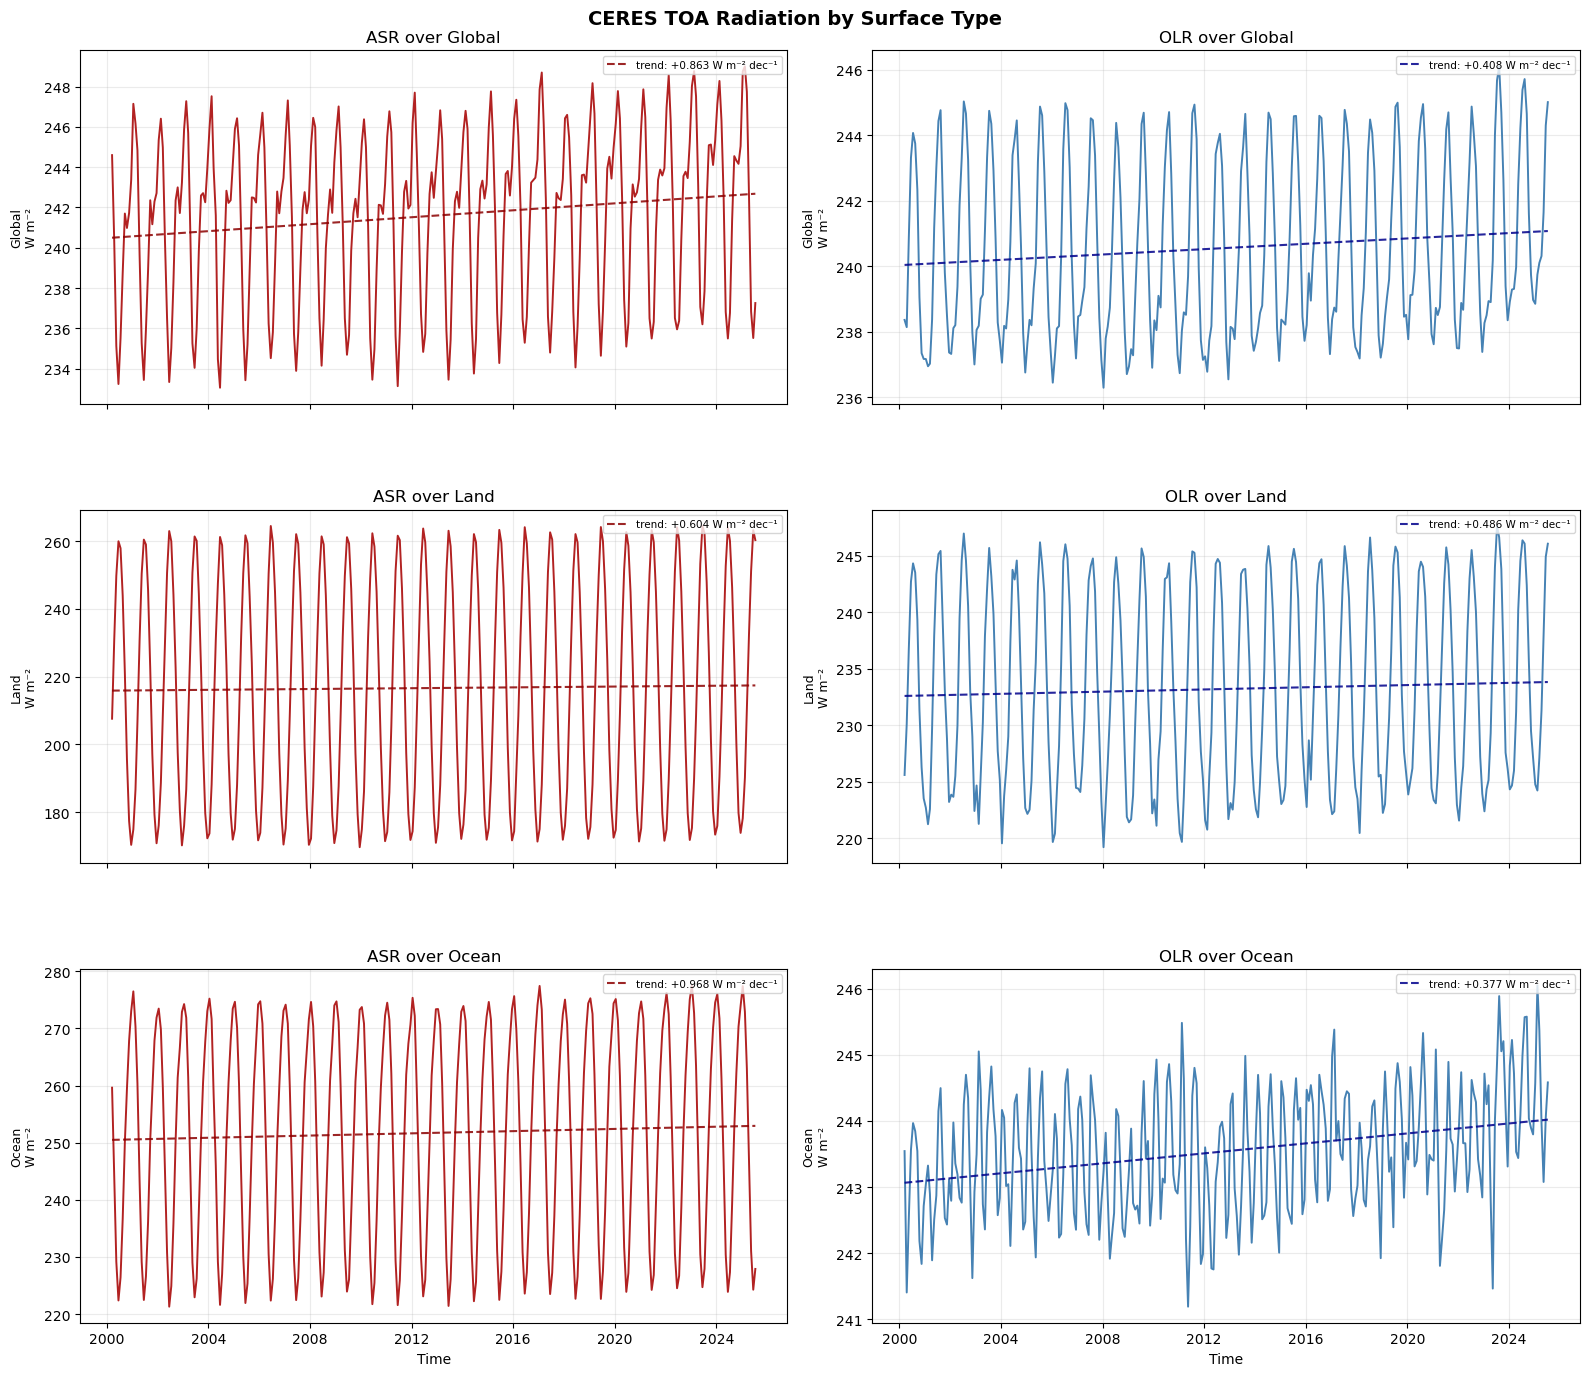

In [29]:

# --- Land/ocean masks ---
lon_180 = (ds.lon.values + 180) % 360 - 180
land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask_np = land_110.mask(lon_180, ds.lat.values)

land_mask  = xr.DataArray(~np.isnan(land_mask_np), dims=["lat","lon"],
                           coords={"lat": ds.lat, "lon": ds.lon})
ocean_mask = ~land_mask

# --- Area-weighted means ---
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"

def wmean(data, mask):
    return data.where(mask).weighted(weights).mean(dim=["lat", "lon"])

# --- ASR ---
ds["asr"] = ds["solar_mon"] - ds["toa_sw_all_mon"]
ds["asr"].attrs = {"long_name": "Absorbed Shortwave Radiation", "units": "W m-2"}

time = ds.time.values

# --- Precompute all means ---
surfaces = {
    "Global": None,
    "Land":   land_mask,
    "Ocean":  ocean_mask,
}

means = {}
for surf, mask in surfaces.items():
    if mask is None:
        means[surf] = {
            "olr": ds["toa_lw_all_mon"].weighted(weights).mean(dim=["lat", "lon"]),
            "asr": ds["asr"].weighted(weights).mean(dim=["lat", "lon"]),
        }
    else:
        means[surf] = {
            "olr": wmean(ds["toa_lw_all_mon"], mask),
            "asr": wmean(ds["asr"], mask),
        }

# --- 3x2 panel: rows = surface types, cols = ASR / OLR ---
row_order = ["Global", "Land", "Ocean"]

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
fig.suptitle("CERES TOA Radiation by Surface Type", fontsize=14, fontweight="bold")

col_titles = ["ASR — Absorbed Shortwave Radiation", "OLR — Outgoing Longwave Radiation"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11)

for row, surf in enumerate(row_order):

    # --- ASR ---
    ax = axes[row, 0]
    asr_vals = means[surf]["asr"].values
    ax.plot(time, asr_vals, color="firebrick", linewidth=1.4)
    add_trend(ax, time, asr_vals, color="darkred")
    ax.set_ylabel(f"{surf}\nW m⁻²", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"ASR over {surf}")

    # --- OLR ---
    ax = axes[row, 1]
    olr_vals = means[surf]["olr"].values
    ax.plot(time, olr_vals, color="steelblue", linewidth=1.4)
    add_trend(ax, time, olr_vals, color="darkblue")
    ax.set_ylabel(f"{surf}\nW m⁻²", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"OLR over {surf}")

for col in range(2):
    axes[-1, col].set_xlabel("Time")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
# plt.savefig("ceres_olr_asr_by_sfc_type_3x2.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# Annual Means

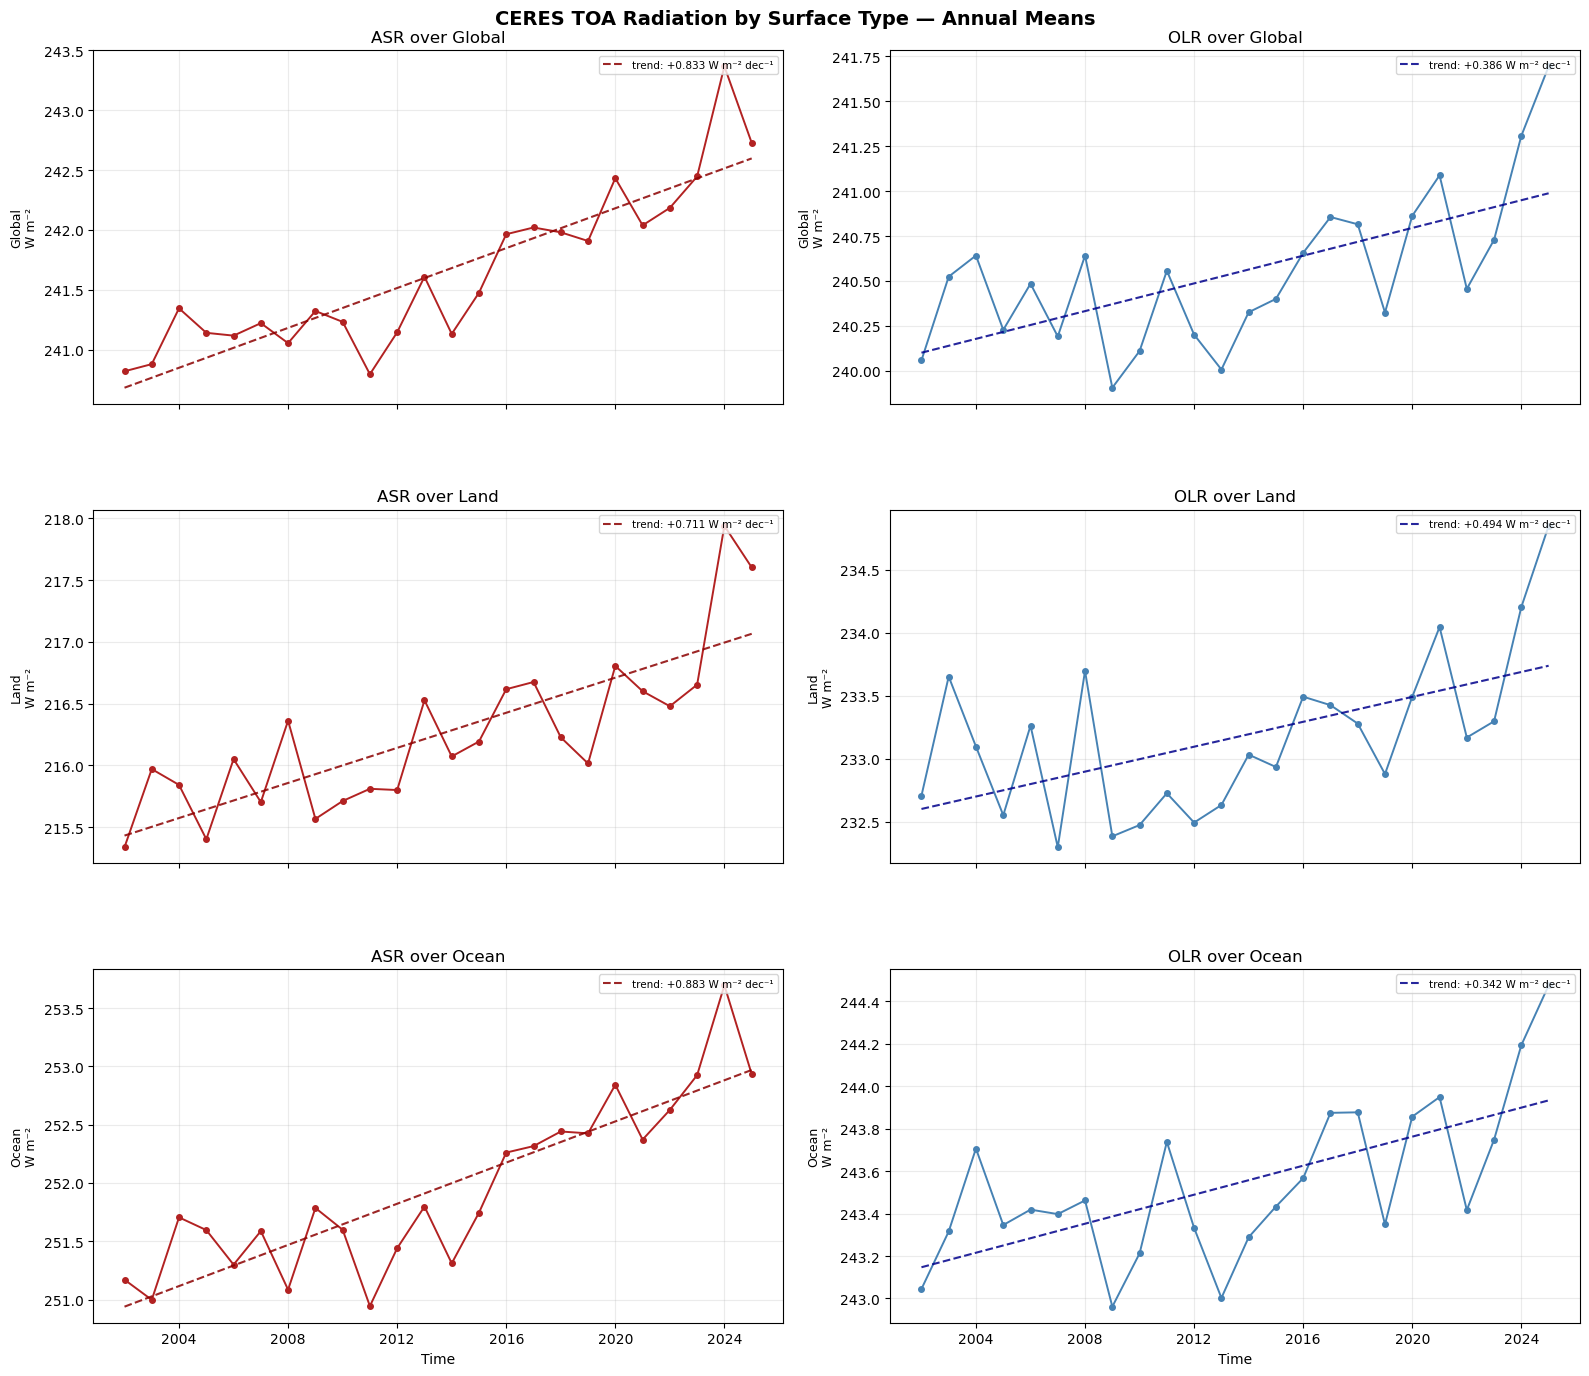

In [31]:
# --- Land/ocean masks ---
lon_180 = (ds.lon.values + 180) % 360 - 180
land_110 = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask_np = land_110.mask(lon_180, ds.lat.values)

land_mask  = xr.DataArray(~np.isnan(land_mask_np), dims=["lat","lon"],
                           coords={"lat": ds.lat, "lon": ds.lon})
ocean_mask = ~land_mask

# --- Area-weighted means ---
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"

def wmean(data, mask):
    return data.where(mask).weighted(weights).mean(dim=["lat", "lon"])

# --- ASR ---
ds["asr"] = ds["solar_mon"] - ds["toa_sw_all_mon"]
ds["asr"].attrs = {"long_name": "Absorbed Shortwave Radiation", "units": "W m-2"}

# --- Precompute annual means ---
surfaces = {
    "Global": None,
    "Land":   land_mask,
    "Ocean":  ocean_mask,
}

# --- Drop partial years ---
full_years = (
    ds["toa_lw_all_mon"]
    .groupby("time.year")
    .count()
    == 12
)
complete_years = full_years.where(full_years, drop=True).year.values
ds_full = ds.sel(time=ds["time.year"].isin(complete_years))

# --- Precompute annual means on complete years only ---
means = {}
for surf, mask in surfaces.items():
    if mask is None:
        olr = ds_full["toa_lw_all_mon"].weighted(weights).mean(dim=["lat", "lon"])
        asr = ds_full["asr"].weighted(weights).mean(dim=["lat", "lon"])
    else:
        olr = wmean(ds_full["toa_lw_all_mon"], mask)
        asr = wmean(ds_full["asr"], mask)
    means[surf] = {
        "olr": olr.resample(time="YE").mean(),
        "asr": asr.resample(time="YE").mean(),
    }
    
time = means["Global"]["olr"].time.values

# --- Trend helper ---
def add_trend(ax, time, values, color):
    x = np.arange(len(time))
    slope, intercept, r, p, _ = stats.linregress(x, values)
    trend = slope * x + intercept
    slope_dec = slope * 10   # per year → per decade
    ax.plot(time, trend, color=color, linewidth=1.5, linestyle="--",
            alpha=0.85, label=f"trend: {slope_dec:+.3f} W m⁻² dec⁻¹")
    ax.legend(fontsize=7.5, loc="upper right")

# --- 3x2 panel: rows = surface types, cols = ASR / OLR ---
row_order = ["Global", "Land", "Ocean"]

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
fig.suptitle("CERES TOA Radiation by Surface Type — Annual Means", fontsize=14, fontweight="bold")

col_titles = ["ASR — Absorbed Shortwave Radiation", "OLR — Outgoing Longwave Radiation"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11)

for row, surf in enumerate(row_order):

    # --- ASR ---
    ax = axes[row, 0]
    asr_vals = means[surf]["asr"].values
    ax.plot(time, asr_vals, color="firebrick", linewidth=1.4, marker="o", markersize=4)
    add_trend(ax, time, asr_vals, color="darkred")
    ax.set_ylabel(f"{surf}\nW m⁻²", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"ASR over {surf}")

    # --- OLR ---
    ax = axes[row, 1]
    olr_vals = means[surf]["olr"].values
    ax.plot(time, olr_vals, color="steelblue", linewidth=1.4, marker="o", markersize=4)
    add_trend(ax, time, olr_vals, color="darkblue")
    ax.set_ylabel(f"{surf}\nW m⁻²", fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.set_title(f"OLR over {surf}")

for col in range(2):
    axes[-1, col].set_xlabel("Time")

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
# plt.savefig("ceres_olr_asr_annual_3x2.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

## Reflected SW and Absorbed SW and Incoming Solar

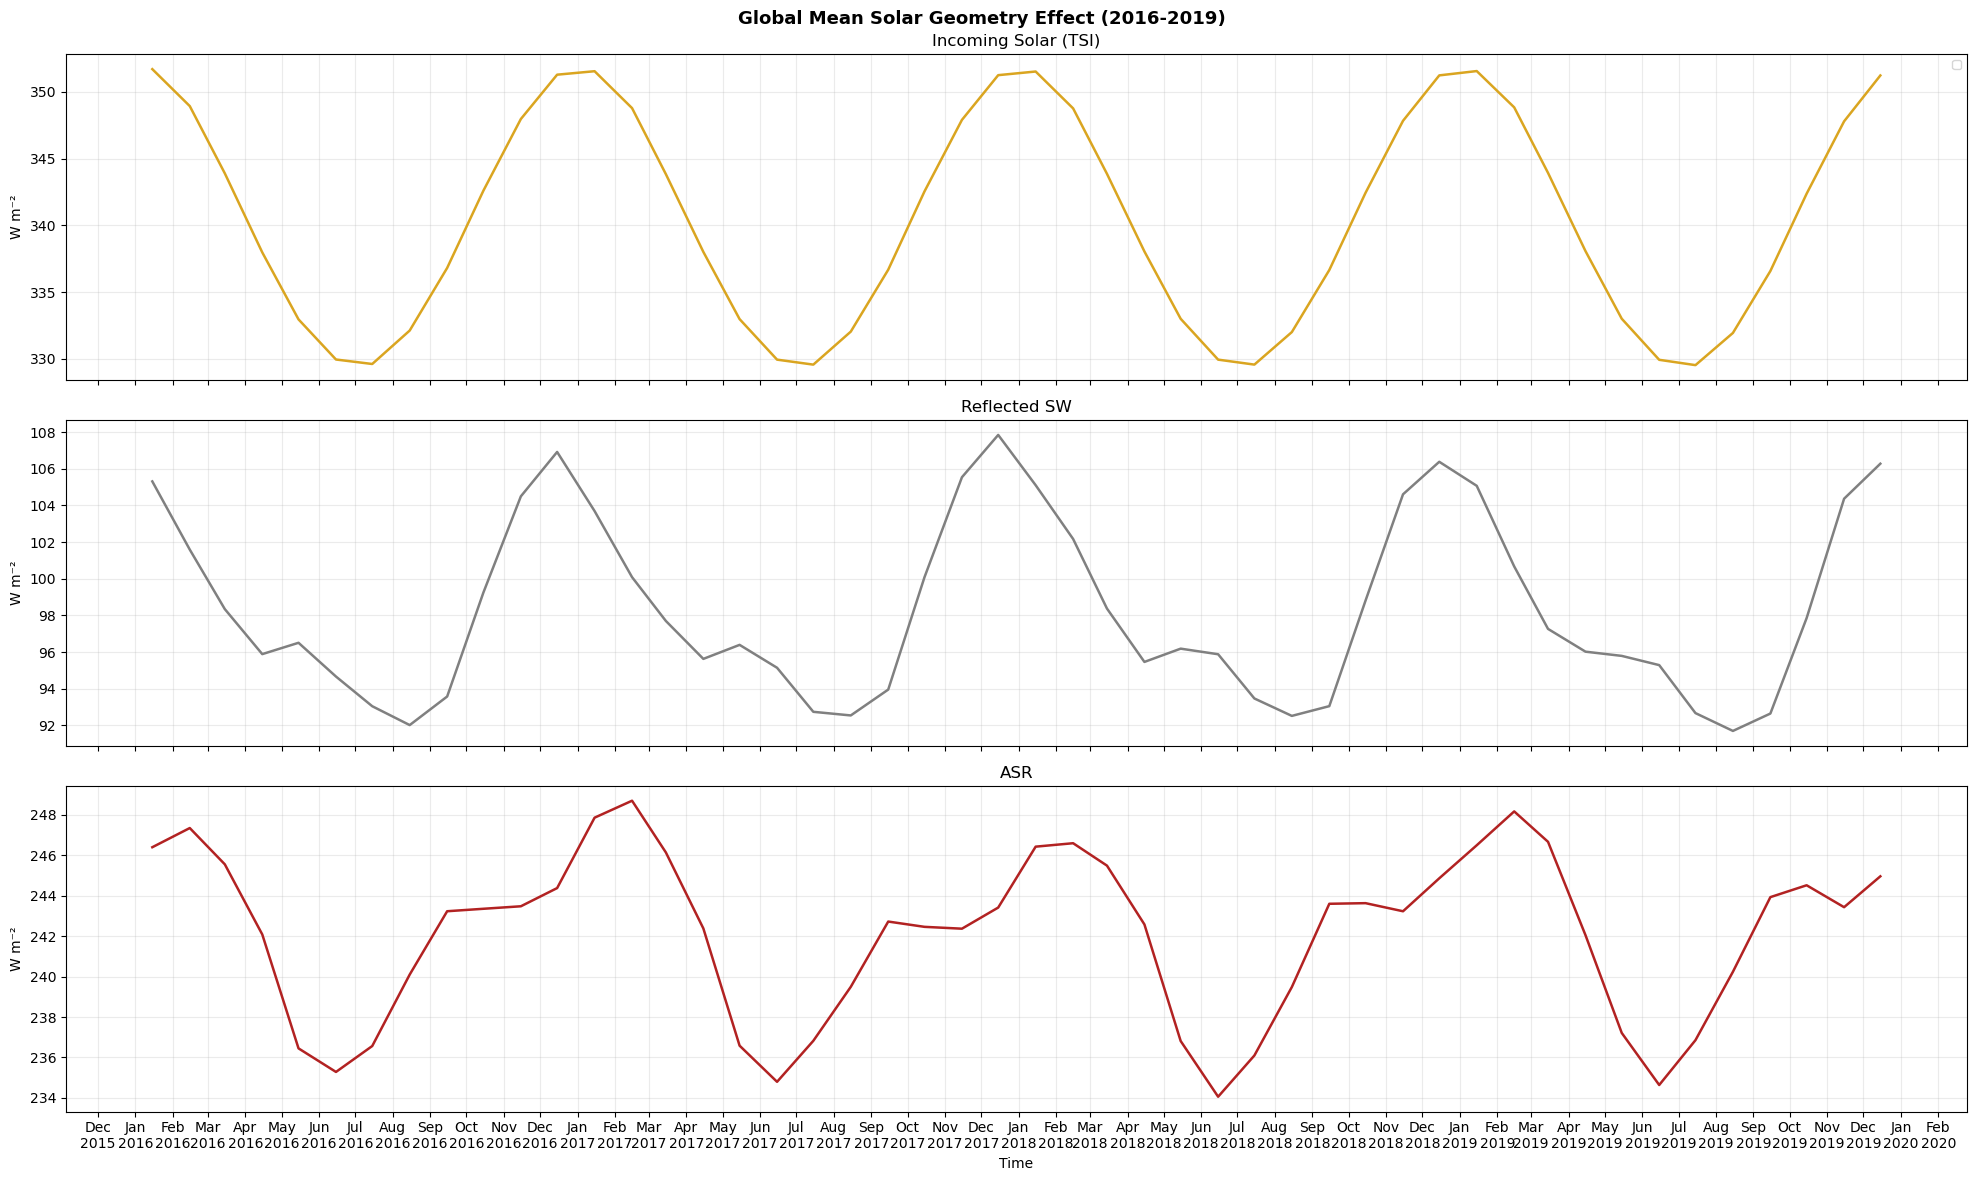

In [36]:
# import matplotlib.pyplot as plt
# import numpy as np

# --- Select 2016-2019 ---
ds_sub = ds.sel(time=slice("2016-01-01", "2019-12-31"))
weights_sub = np.cos(np.deg2rad(ds_sub.lat))
weights_sub.name = "weights"

time_sub = ds_sub.time.values

# --- Global means for the sub-period ---
solar_global = ds_sub["solar_mon"].weighted(weights_sub).mean(dim=["lat", "lon"])
asr_global   = (ds_sub["solar_mon"] - ds_sub["toa_sw_all_mon"]).weighted(weights_sub).mean(dim=["lat", "lon"])
sw_refl      = ds_sub["toa_sw_all_mon"].weighted(weights_sub).mean(dim=["lat", "lon"])

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(20, 12))
fig.suptitle("Global Mean Solar Geometry Effect (2016-2019)", fontsize=13, fontweight="bold")

axes[0].plot(time_sub, solar_global.values, color="goldenrod", linewidth=1.8)
axes[0].set_ylabel("W m⁻²")
axes[0].set_title("Incoming Solar (TSI)")
axes[0].grid(True, alpha=0.25)

axes[1].plot(time_sub, sw_refl.values, color="gray", linewidth=1.8)
axes[1].set_ylabel("W m⁻²")
axes[1].set_title("Reflected SW")
axes[1].grid(True, alpha=0.25)

axes[2].plot(time_sub, asr_global.values, color="firebrick", linewidth=1.8)
axes[2].set_ylabel("W m⁻²")
axes[2].set_title("ASR")
axes[2].grid(True, alpha=0.25)

# --- Annotate equinoxes and solstices ---
events = {
    "Mar\nEquinox": ["2016-03-20", "2017-03-20", "2018-03-20", "2019-03-20"],
    "Jun\nSolstice": ["2016-06-20", "2017-06-21", "2018-06-21", "2019-06-21"],
    "Sep\nEquinox":  ["2016-09-22", "2017-09-22", "2018-09-23", "2019-09-23"],
    "Dec\nSolstice": ["2016-12-21", "2017-12-21", "2018-12-22", "2019-12-22"],
}
event_colors = {
    "Mar\nEquinox": "green",
    "Jun\nSolstice": "orange",
    "Sep\nEquinox":  "green",
    "Dec\nSolstice": "orange",
}

# for ax in axes:
#     for label, dates in events.items():
#         for i, d in enumerate(dates):
#             ax.axvline(np.datetime64(d), color=event_colors[label],
#                        linewidth=0.8, linestyle="--", alpha=0.6,
#                        label=label if i == 0 else "")

# Single shared legend on top panel
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, fontsize=8, loc="upper right", ncol=4)

axes[-1].set_xlabel("Time")

import matplotlib.dates as mdates

# --- Label every month on the bottom panel only ---
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

# Only show year on tick where year changes, clean up redundant year labels
for ax in axes[:-1]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

fig.autofmt_xdate(rotation=0, ha="center")

plt.tight_layout()
# plt.savefig("ceres_solar_geometry_2016_2019.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

## Separate NH and SH

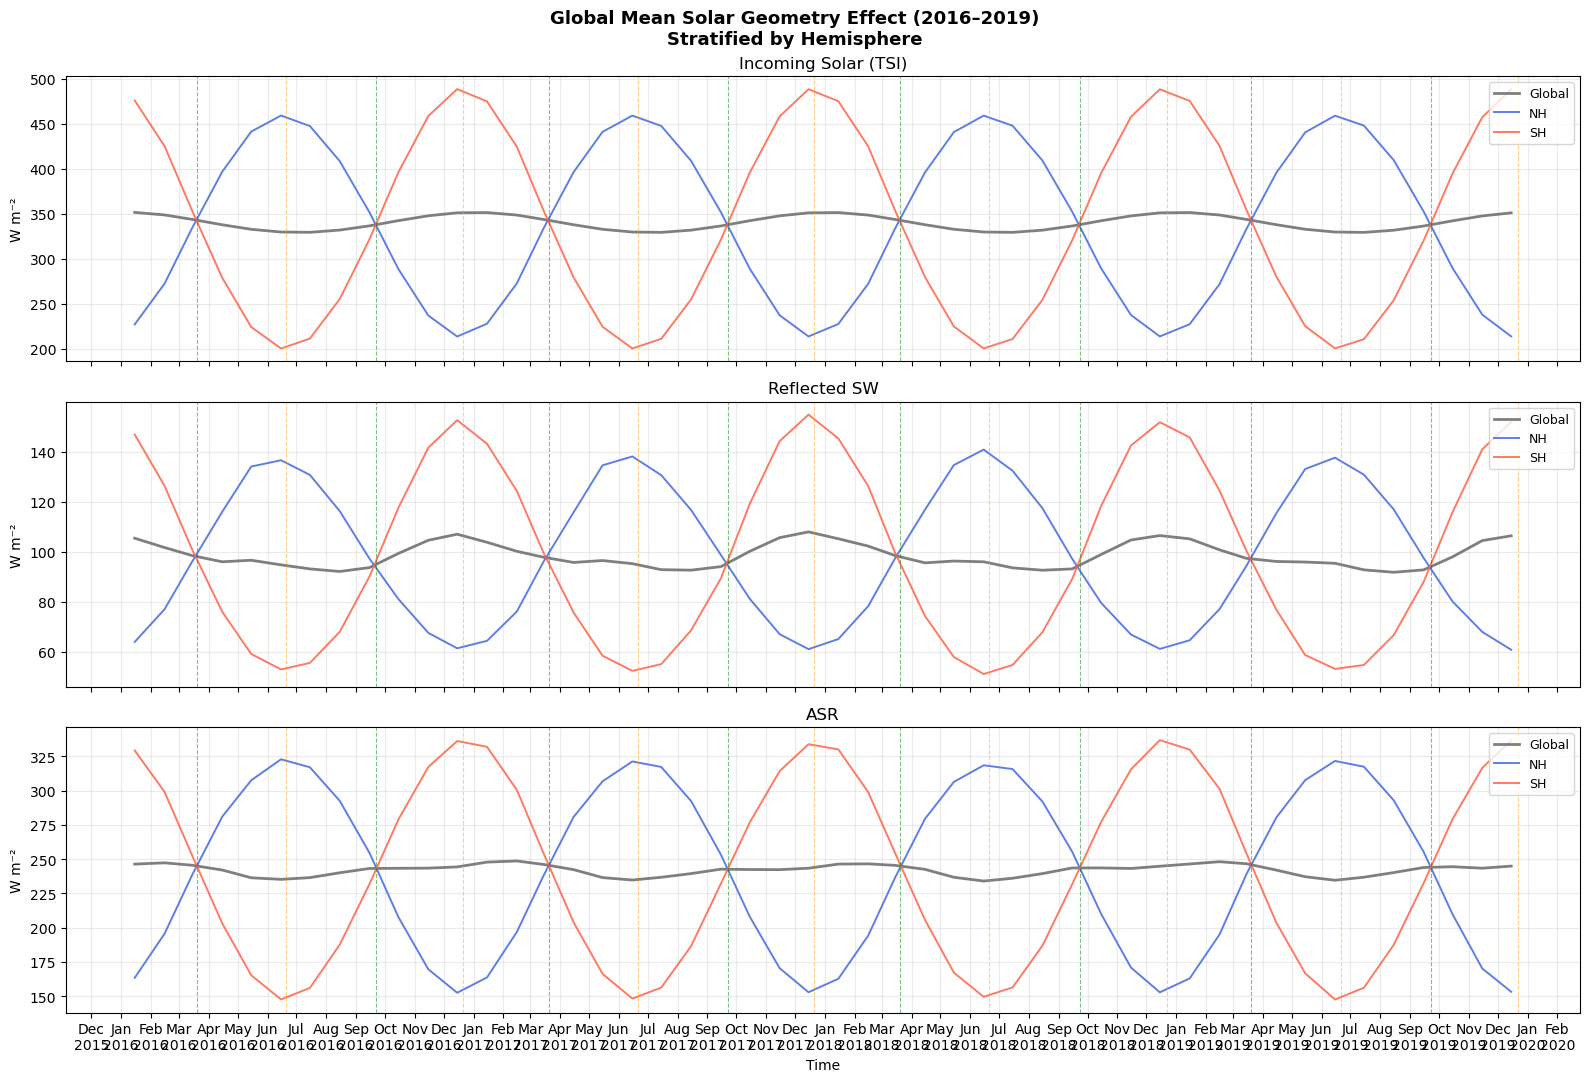

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# --- Select 2016-2019 ---
ds_sub = ds.sel(time=slice("2016-01-01", "2019-12-31"))
weights_sub = np.cos(np.deg2rad(ds_sub.lat))
weights_sub.name = "weights"

time_sub = ds_sub.time.values

# --- Hemisphere masks ---
nh_mask = ds_sub.lat >= 0
sh_mask = ds_sub.lat < 0

def wmean_hem(data, mask):
    return data.sel(lat=mask).weighted(
        weights_sub.sel(lat=mask)
    ).mean(dim=["lat", "lon"])

# --- Global, NH, SH means ---
def compute_means(ds_):
    w = np.cos(np.deg2rad(ds_.lat))
    w.name = "weights"
    return {
        "Global": ds_.weighted(w).mean(dim=["lat", "lon"]),
        "NH":     wmean_hem(ds_, ds_.lat >= 0),
        "SH":     wmean_hem(ds_, ds_.lat <  0),
    }

solar_means = compute_means(ds_sub["solar_mon"])
refl_means  = compute_means(ds_sub["toa_sw_all_mon"])
asr_means   = compute_means(ds_sub["solar_mon"] - ds_sub["toa_sw_all_mon"])

# --- Colors and styles per hemisphere ---
hem_styles = {
    "Global": ("dimgray",    "-",  2.0),
    "NH":     ("royalblue",  "-",  1.4),
    "SH":     ("tomato",     "-",  1.4),
}

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle("Global Mean Solar Geometry Effect (2016–2019)\nStratified by Hemisphere",
             fontsize=13, fontweight="bold")

panel_data = [
    ("Incoming Solar (TSI)",  "goldenrod", solar_means),
    ("Reflected SW",          "gray",      refl_means),
    ("ASR",                   "firebrick", asr_means),
]

for ax, (title, _, means) in zip(axes, panel_data):
    for hem, (color, ls, lw) in hem_styles.items():
        ax.plot(time_sub, means[hem].values, color=color, linestyle=ls,
                linewidth=lw, label=hem, alpha=0.85)
    ax.set_ylabel("W m⁻²")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc="upper right")

# --- Annotate equinoxes and solstices ---
events = {
    "Mar\nEquinox": ["2016-03-20", "2017-03-20", "2018-03-20", "2019-03-20"],
    "Jun\nSolstice": ["2016-06-20", "2017-06-21", "2018-06-21", "2019-06-21"],
    "Sep\nEquinox":  ["2016-09-22", "2017-09-22", "2018-09-23", "2019-09-23"],
    "Dec\nSolstice": ["2016-12-21", "2017-12-21", "2018-12-22", "2019-12-22"],
}
event_colors = {
    "Mar\nEquinox": "green", "Jun\nSolstice": "orange",
    "Sep\nEquinox": "green", "Dec\nSolstice": "orange",
}

for ax in axes:
    for label, dates in events.items():
        for i, d in enumerate(dates):
            ax.axvline(np.datetime64(d), color=event_colors[label],
                       linewidth=0.8, linestyle="--", alpha=0.5,
                       label=label if i == 0 else "")

# --- Monthly x-axis labels ---
for ax in axes[:-1]:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

fig.autofmt_xdate(rotation=0, ha="center")
axes[-1].set_xlabel("Time")

plt.tight_layout()
# plt.savefig("ceres_solar_geometry_hemispheres.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()